In [1]:
# Libraries
# scipy, numpy, pandas, matplotlib, seaborn and scikit-learn

from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split


# parameter tuning
from sklearn.preprocessing import StandardScaler

# Additional libraries

from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error






In [3]:
data = '2_income_Regression.csv '

In [4]:
df = pd.read_csv(data)
df.head(10)

,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398
5,6,3.729643,2.458556
6,7,4.674517,3.192992
7,8,4.498104,1.907137
8,9,3.121631,2.942450
9,10,4.639914,3.737942


In [5]:
# train test split with cross validation
df = df.drop(columns = ['Unnamed: 0'])
y_values = df['happiness']
X_values = df.drop(columns=['happiness'])

X_train, X_test, y_train, y_test = train_test_split(X_values, y_values, test_size=.20, random_state=123)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [6]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)

IQR = Q3-Q1

lower_bound = Q1 - (IQR*1.5)
upper_bound = Q3 + (IQR*1.5)

outliers = ((X_train < lower_bound) | (X_train > upper_bound)).any(axis = 1)

print('Outliers:', X_train[outliers].shape)


Outliers: (0, 1)


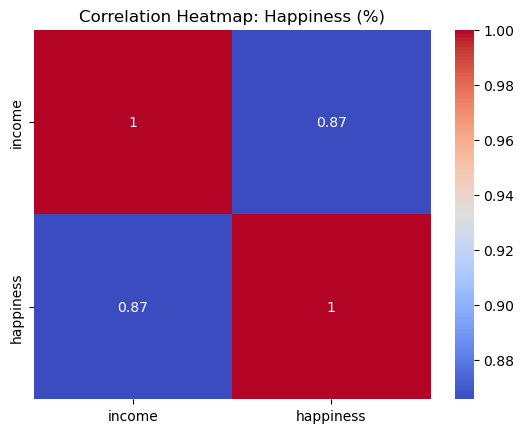

In [7]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap= "coolwarm", annot= True)
plt.title("Correlation Heatmap: Happiness (%)", fontsize=12, fontweight='bold')
plt.show()

### Linear Regression

In [8]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
predictions = regression_model.predict(X_train)
residuals = y_train - predictions

#### Validiation of Assumptions

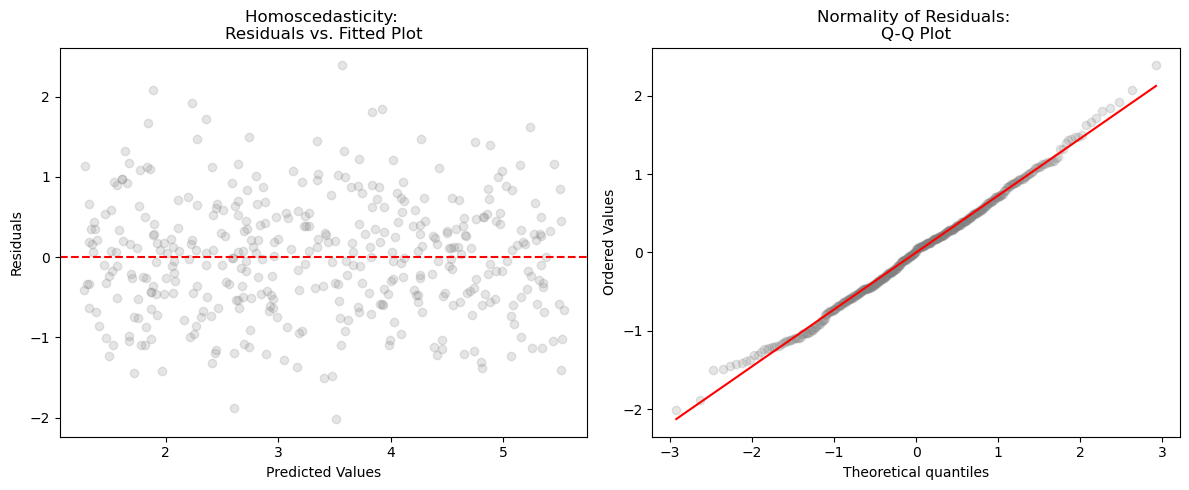

In [10]:
#to prove homoscedasticity (constant variance of residuals) and normality of residuals
fig, ax = plt.subplots(1, 2, figsize= (12, 5))


ax[0].scatter(predictions, residuals, alpha=0.2, color = 'grey')
ax[0].axhline(y=0, color = 'red', linestyle='--')
ax[0].set_xlabel('Predicted Values')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Homoscedasticity: \nResiduals vs. Fitted Plot', fontsize=12, fontweight='bold')


stats.probplot(residuals, dist=stats.norm, plot= ax[1])
ax[1].set_title("Normality of Residuals: \nQ-Q Plot", fontsize=12, fontweight='bold')
qq = ax[1].get_lines()
qq[0].set_color('grey')
qq[0].set_alpha(0.2)
plt.tight_layout()
plt.show()

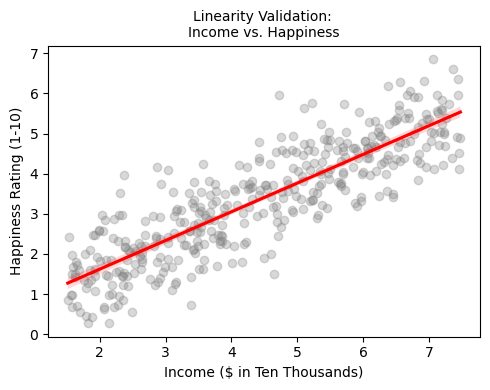

In [18]:
# proving linearity
plt.figure(figsize=(5,4))
sns.regplot(x=X_train['income'], 
            y=y_train,
            scatter_kws={'alpha':0.3, 'color':'grey'}, 
            line_kws={'color':'red'})
plt.title('Linearity Validation: \nIncome vs. Happiness', fontsize=10, fontweight='bold')
plt.xlabel('Income ($ in Ten Thousands)')
plt.ylabel('Happiness Rating (1-10)')


plt.tight_layout()
plt.show()

In [19]:

# independence of errors
durbin_watson = durbin_watson(residuals)
print(f"Durbin-Watson score: {durbin_watson:.4f}")

# data does not violate any assumptions

Durbin-Watson score: 2.1320


### Model Coefficient Evaluation

$$\text{Happiness Rating (1-10)} = \beta_0 + (\beta_1 \times \text{Income (\$ in Ten Thousands)})$$


In [23]:
X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)


linear_model = sm.OLS(y_train, X_train_ols).fit()  # Fitting the OLS model

In [25]:
print(f"Intercept (Beta 0): {regression_model.intercept_:.4f}\n")
print(f"Coefficient (Beta 1): {regression_model.coef_[0]:.4f}\n")


Intercept (Beta 0): 0.1912

Coefficient (Beta 1): 0.7146



In [30]:
print(linear_model.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1912      0.101      1.900      0.058      -0.007       0.389
income         0.7146      0.021     33.630      0.000       0.673       0.756


### Performance Evaluation & Error Metrics

In [ ]:
y_pred_test = regression_model.predict(X_test)


mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test) 
r2_test = r2_score(y_test, y_pred_test)


print(f"Mean Squared Error (MSE):  {mse_test:.4f}%")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}%")
print(f"R2: {r2_test*100:.4f}")

coefficients = regression_model.coef_
intercept = regression_model.intercept_


### Summary

##### The model produces a  mean squared error (MSE) of 0.47% and a root mean square error (RMSE) of 0.68%. The **$R^2$ score of 0.77 indicates independent variables account for 77.72% of the total variance in the target variable. 

##### In an imaginary sample of 500 towns, every \\$10,000 increase of income is estimated to increase the happiness rating by 0.7146 points.  It is with 95% confidence, the increase in happiness falls between 0.673 and 0.756 points, for every \\$10,000 increase of income.  A p-value of 0.0 indicates variable to be statistically significant predictor to the model.